# **Introduction**

---



This project focuses on applying optimization techniques in machine learning for predicting house prices. The study compares traditional gradient-based optimization with evolutionary and swarm-based optimization methods

**Problem Statement**

The goal is to minimize prediction error in house price estimation using optimization techniques.

**Objective**
*   Implement Gradient Descent
*   Apply Genetic Algorithm for feature selection


*   Use PSO for hyperparameter tuning
*  Compare performance





In [1]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df = df.fillna(df.mean(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,True,False,False,False
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,True,False,False,False
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,True,False,False,False
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,True,False,False,False


In [7]:
X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values.reshape(-1,1)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


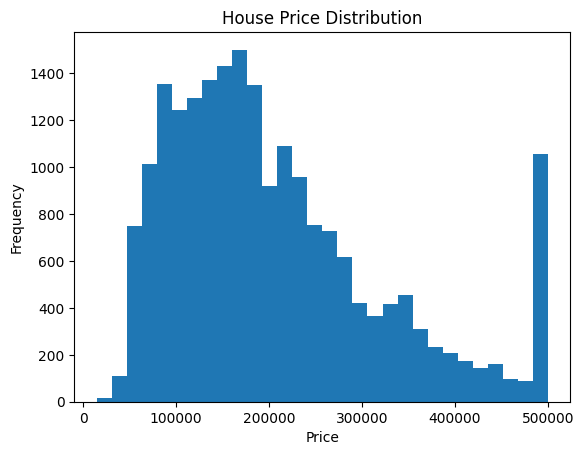

In [10]:
plt.hist(y, bins=30)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [11]:
def compute_loss(X, y, w, b):
    n = len(y)
    y_pred = X @ w + b
    return np.sum((y - y_pred)**2) / n

In [12]:
def gradient_descent(X, y, lr=0.01, epochs=100):
    w = np.zeros((X.shape[1],1))
    b = 0
    loss_history = []

    for _ in range(epochs):
        y_pred = X @ w + b

        dw = (-2/len(y)) * X.T @ (y - y_pred)
        db = (-2/len(y)) * np.sum(y - y_pred)

        w -= lr * dw
        b -= lr * db

        loss = compute_loss(X, y, w, b)
        loss_history.append(loss)

    return w, b, loss_history

In [13]:
w_gd, b_gd, loss_gd = gradient_descent(X_train, y_train)

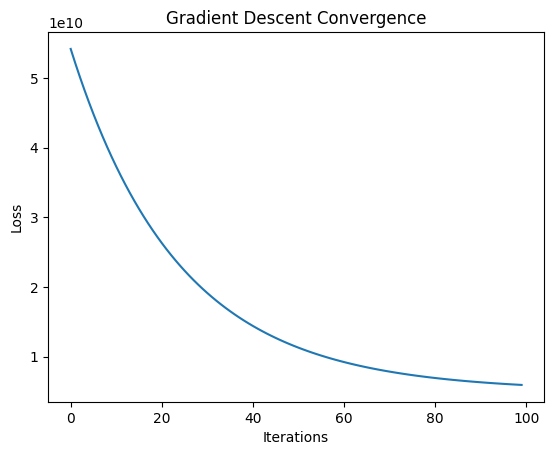

In [14]:
plt.plot(loss_gd)
plt.title("Gradient Descent Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [15]:
def evaluate(X, y, w, b):
    y_pred = X @ w + b
    mse = np.mean((y - y_pred)**2)
    rmse = np.sqrt(mse)
    r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
    return mse, rmse, r2

In [16]:
mse_gd, rmse_gd, r2_gd = evaluate(X_test, y_test, w_gd, b_gd)
print(mse_gd, rmse_gd, r2_gd)

6021176246.960425 77596.23861348194 0.5405116763589879


In [17]:
# -----------------------------
# GENETIC ALGORITHM FOR FEATURE SELECTION
# -----------------------------

pop_size = 20
n_features = X_train.shape[1]
generations = 20
ga_loss_history = []

# Initialize population (0 = not selected, 1 = selected)
population = np.random.randint(0, 2, (pop_size, n_features))

def fitness(chromosome):
    selected_idx = np.where(chromosome == 1)[0]

    # If no features selected → bad solution
    if len(selected_idx) == 0:
        return 1e10

    X_sub = X_train[:, selected_idx]

    w, b, _ = gradient_descent(X_sub, y_train, epochs=50)
    loss = compute_loss(X_sub, y_train, w, b)

    return loss  # minimize loss


for gen in range(generations):

    scores = np.array([fitness(ind) for ind in population])
    best_score = np.min(scores)
    ga_loss_history.append(best_score)

    # Select best 50%
    selected_idx = np.argsort(scores)[:pop_size//2]
    selected = population[selected_idx]

    # Crossover
    children = []
    for i in range(len(selected)-1):
        p1, p2 = selected[i], selected[i+1]
        point = np.random.randint(1, n_features)
        child = np.concatenate([p1[:point], p2[point:]])
        children.append(child)

    children = np.array(children)

    # Mutation
    mutation = np.random.rand(*children.shape) < 0.1
    children = np.logical_xor(children, mutation).astype(int)

    # New population
    population = np.vstack((selected, children))


# Best chromosome
best = population[np.argmin([fitness(ind) for ind in population])]
selected_features = np.where(best == 1)[0]

print("Selected Features Index:", selected_features)

Selected Features Index: [ 0  1  2  3  4  5  6  7  8  9 10 11]


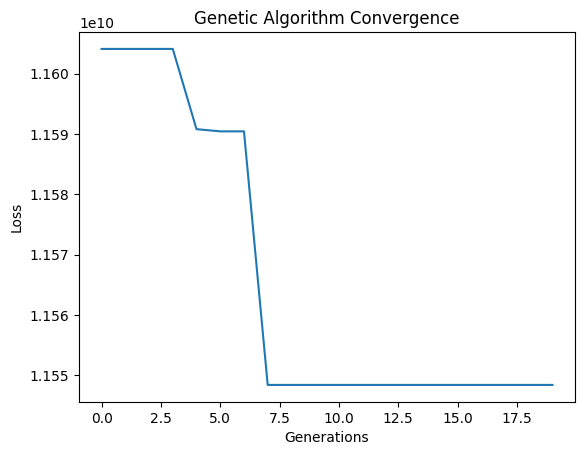

In [18]:
plt.plot(ga_loss_history)
plt.title("Genetic Algorithm Convergence")
plt.xlabel("Generations")
plt.ylabel("Loss")
plt.show()

In [19]:
# Train model using selected features
X_train_ga = X_train[:, selected_features]
X_test_ga = X_test[:, selected_features]

w_ga, b_ga, _ = gradient_descent(X_train_ga, y_train)

mse_ga, rmse_ga, r2_ga = evaluate(X_test_ga, y_test, w_ga, b_ga)

print("Genetic Algorithm:", mse_ga, rmse_ga, r2_ga)

Genetic Algorithm: 6021176246.960425 77596.23861348194 0.5405116763589879


In [20]:
# -----------------------------
# PARTICLE SWARM OPTIMIZATION
# -----------------------------

n_particles = 10
particles = np.random.uniform(0.0001, 0.1, n_particles)
velocity = np.zeros(n_particles)
pso_loss_history = []

pbest = particles.copy()
pbest_scores = np.array([1e10]*n_particles)


def evaluate_lr(lr):
    w, b, _ = gradient_descent(X_train, y_train, lr=lr, epochs=50)
    return compute_loss(X_train, y_train, w, b)


for iter in range(30):

    for i in range(n_particles):
        score = evaluate_lr(particles[i])

        if score < pbest_scores[i]:
            pbest[i] = particles[i]
            pbest_scores[i] = score

    # Global best
    gbest = pbest[np.argmin(pbest_scores)]
    best_loss = evaluate_lr(gbest)
    pso_loss_history.append(best_loss)

    # Update velocity & position
    for i in range(n_particles):
        velocity[i] = (
            0.5 * velocity[i]
            + 1.5 * np.random.rand() * (pbest[i] - particles[i])
            + 1.5 * np.random.rand() * (gbest - particles[i])
        )

        particles[i] += velocity[i]


print("Best Learning Rate from PSO:", gbest)

Best Learning Rate from PSO: 0.24949729291500514


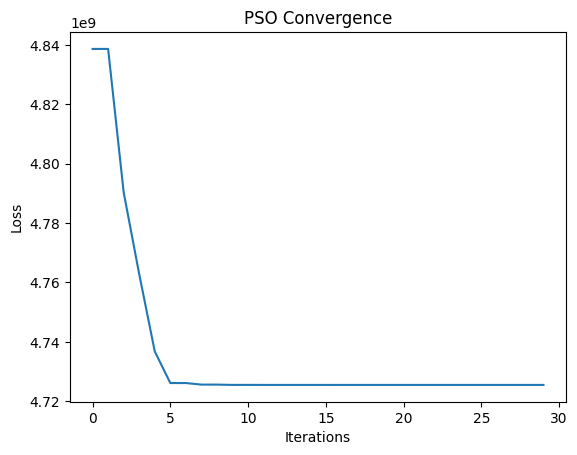

In [21]:
plt.plot(pso_loss_history)
plt.title("PSO Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [22]:
# Train with best learning rate
w_pso, b_pso, _ = gradient_descent(X_train, y_train, lr=gbest)

mse_pso, rmse_pso, r2_pso = evaluate(X_test, y_test, w_pso, b_pso)

print("PSO:", mse_pso, rmse_pso, r2_pso)

PSO: 4880351348.540522 69859.5115108925 0.6275703669939798


In [23]:
particles = np.random.uniform(0.001, 0.1, 10)
vel = np.zeros(10)
pbest = particles.copy()

In [24]:
print("\n--- FINAL COMPARISON ---")
print("Gradient Descent :", mse_gd, rmse_gd, r2_gd)
print("Genetic Algorithm:", mse_ga, rmse_ga, r2_ga)
print("PSO             :", mse_pso, rmse_pso, r2_pso)


--- FINAL COMPARISON ---
Gradient Descent : 6021176246.960425 77596.23861348194 0.5405116763589879
Genetic Algorithm: 6021176246.960425 77596.23861348194 0.5405116763589879
PSO             : 4880351348.540522 69859.5115108925 0.6275703669939798


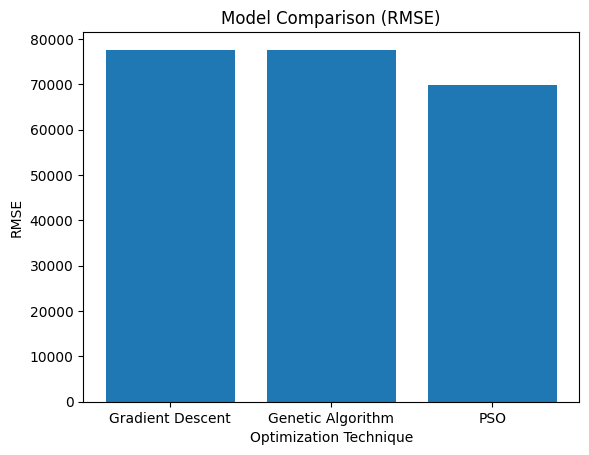

In [25]:
methods = ['Gradient Descent', 'Genetic Algorithm', 'PSO']
rmse_values = [rmse_gd, rmse_ga, rmse_pso]

plt.bar(methods, rmse_values)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xlabel("Optimization Technique")
plt.show()

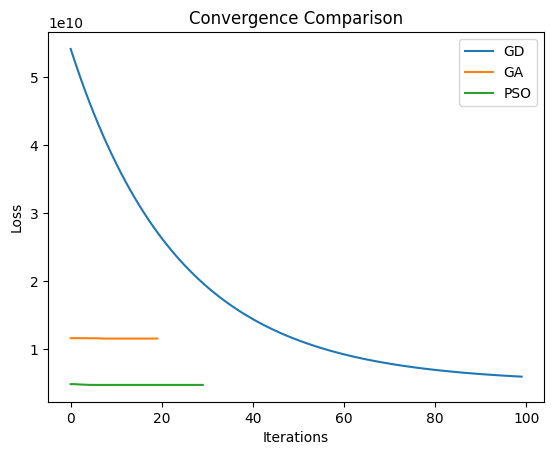

In [26]:
plt.plot(loss_gd, label="GD")
plt.plot(ga_loss_history, label="GA")
plt.plot(pso_loss_history, label="PSO")

plt.title("Convergence Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()